# 🏥 Healthcare Diabetes Analysis

## Problem Statement
Identify key health indicators that influence diabetes risk by comparing diabetic vs non-diabetic patients using the Pima Indians Diabetes Dataset.

## Dataset
- **Source:** Pima Indians Diabetes Database (Kaggle)
- **Rows:** 768 patients
- **Columns:** 9 health indicators
- **Target:** Outcome (0 = Non-Diabetic, 1 = Diabetic)

## Tools Used
Python | Pandas | NumPy | Matplotlib | Seaborn | Jupyter Notebook

## Workflow
1. Data Loading & Understanding
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Visualizations
5. Key Insights & Conclusions

## About This Analysis
This project was completed as part of my Data Analytics portfolio. The goal was to explore real-world healthcare data, handle data quality issues, and derive meaningful insights about diabetes risk factors.

In [2]:
# ================================================
# CELL 2: Import Libraries
# ================================================

import pandas as pd          # data manipulation
import numpy as np           # numerical operations
import matplotlib.pyplot as plt  # plotting
import seaborn as sns        # advanced visualizations

# Show plots inside notebook
%matplotlib inline

# Set consistent style for all plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [3]:
# ================================================
# CELL 3: Load Dataset
# ================================================

# Load the diabetes CSV file
df = pd.read_csv("diabetes.csv")

# Quick look at the data
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 🔍 Section 1: Data Understanding
Getting familiar with the dataset — 
its shape, columns, data types, and basic statistics.

In [5]:
# ================================================
# CELL 5: Understand Data Structure
# ================================================

print("Dataset Info:")
print("-" * 40)
print(df.info())

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [6]:
# ================================================
# CELL 6: Basic Statistics
# ================================================

print("Statistical Summary:")
print("-" * 40)
df.describe()

# NOTE: Look at the MIN row carefully
# You will see 0 values in medical columns
# A person cannot have 0 Glucose or 0 BMI
# These are hidden missing values — fixed in next section

Statistical Summary:
----------------------------------------


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 🧹 Section 2: Data Cleaning

**Key Finding:** Zero values exist in medical columns 
where zeros are medically impossible.

A living person cannot have:
- 0 Glucose
- 0 Blood Pressure
- 0 BMI
- 0 Insulin
- 0 Skin Thickness

These zeros actually represent **missing/unrecorded values**.

**Fix:** Replace zeros with NaN → Fill using column median.
Median is preferred over mean because medical data 
is often skewed by extreme values.

In [8]:
# ================================================
# CELL 8: Find Hidden Zeros
# KEY INSIGHT: This dataset has a data quality issue
# Medical columns contain 0s where 0 is impossible
# This is a common real-world data problem
# Solution: Replace 0s with NaN → fill with median
# ================================================

medical_columns = ['Glucose', 'BloodPressure', 
                   'SkinThickness', 'Insulin', 'BMI']

print("Hidden zeros in medical columns:")
print("-" * 45)
for col in medical_columns:
    zero_count = (df[col] == 0).sum()
    percentage = (zero_count / len(df)) * 100
    print(f"{col:25} → {zero_count} zeros ({percentage:.1f}%)")

Hidden zeros in medical columns:
---------------------------------------------
Glucose                   → 5 zeros (0.7%)
BloodPressure             → 35 zeros (4.6%)
SkinThickness             → 227 zeros (29.6%)
Insulin                   → 374 zeros (48.7%)
BMI                       → 11 zeros (1.4%)


In [9]:
# ================================================
# CELL 9: Clean Data Function
# Using a function shows structured code thinking
# ================================================

def clean_data(df):
    """
    Replaces medically impossible zero values 
    with NaN and fills using column median.
    
    Parameters: df → raw DataFrame
    Returns:    df → cleaned DataFrame
                original_zeros → zero counts before cleaning
    """
    medical_columns = ['Glucose', 'BloodPressure', 
                       'SkinThickness', 'Insulin', 'BMI']
    
    # Save zero counts BEFORE cleaning for comparison
    original_zeros = (df[medical_columns] == 0).sum()
    
    # Step 1: Replace zeros with NaN
    df[medical_columns] = df[medical_columns].replace(0, np.nan)
    
    # Step 2: Fill NaN with median of each column
    for col in medical_columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"{col:25} → filled with median: {median_val:.2f}")
    
    return df, original_zeros

# Call the function
df, original_zeros = clean_data(df)
print("\n✅ Data cleaning complete!")

Glucose                   → filled with median: 117.00
BloodPressure             → filled with median: 72.00
SkinThickness             → filled with median: 29.00
Insulin                   → filled with median: 125.00
BMI                       → filled with median: 32.30

✅ Data cleaning complete!


In [10]:
# ================================================
# CELL 10: Before vs After Cleaning Comparison
# This PROVES our cleaning actually worked
# ================================================

print("=" * 50)
print("    BEFORE vs AFTER CLEANING COMPARISON")
print("=" * 50)

print("\n❌ Hidden zeros BEFORE cleaning:")
print("-" * 40)
for col, count in original_zeros.items():
    pct = (count / len(df)) * 100
    print(f"{col:25} → {count} zeros ({pct:.1f}%)")

print("\n✅ Missing values AFTER cleaning:")
print("-" * 40)
print(df.isnull().sum())
print("\n✅ All missing values successfully handled!")

    BEFORE vs AFTER CLEANING COMPARISON

❌ Hidden zeros BEFORE cleaning:
----------------------------------------
Glucose                   → 5 zeros (0.7%)
BloodPressure             → 35 zeros (4.6%)
SkinThickness             → 227 zeros (29.6%)
Insulin                   → 374 zeros (48.7%)
BMI                       → 11 zeros (1.4%)

✅ Missing values AFTER cleaning:
----------------------------------------
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

✅ All missing values successfully handled!


## 📊 Section 3: Exploratory Data Analysis (EDA)

Now that data is clean, we explore patterns and 
differences between diabetic and non-diabetic patients.

### Charts we will create:
1. Outcome Distribution (Pie Chart)
2. Correlation Heatmap
3. Feature Importance Ranking
4. Glucose Distribution
5. BMI Box Plot
6. Age Distribution
7. All Features Comparison

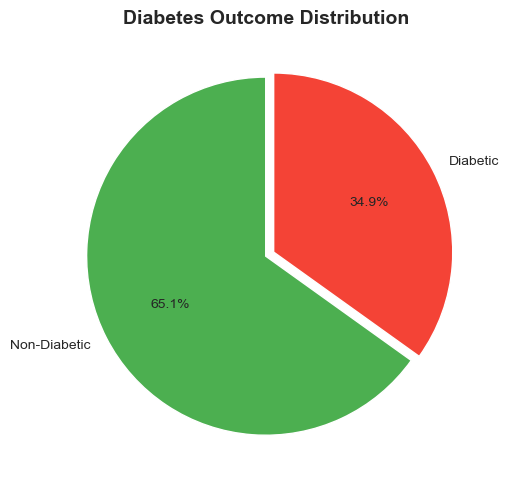

Non-Diabetic : 500 (65.1%)
Diabetic     : 268 (34.9%)


In [12]:
# ================================================
# CELL 12: Outcome Distribution — Pie Chart
# ================================================

outcome_counts = df['Outcome'].value_counts()

plt.figure(figsize=(7, 5))
plt.pie(outcome_counts,
        labels=['Non-Diabetic', 'Diabetic'],
        autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336'],
        startangle=90,
        explode=(0, 0.05))

plt.title('Diabetes Outcome Distribution',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/outcome_distribution.png', dpi=150)
plt.show()

print(f"Non-Diabetic : {outcome_counts[0]} ({outcome_counts[0]/len(df)*100:.1f}%)")
print(f"Diabetic     : {outcome_counts[1]} ({outcome_counts[1]/len(df)*100:.1f}%)")

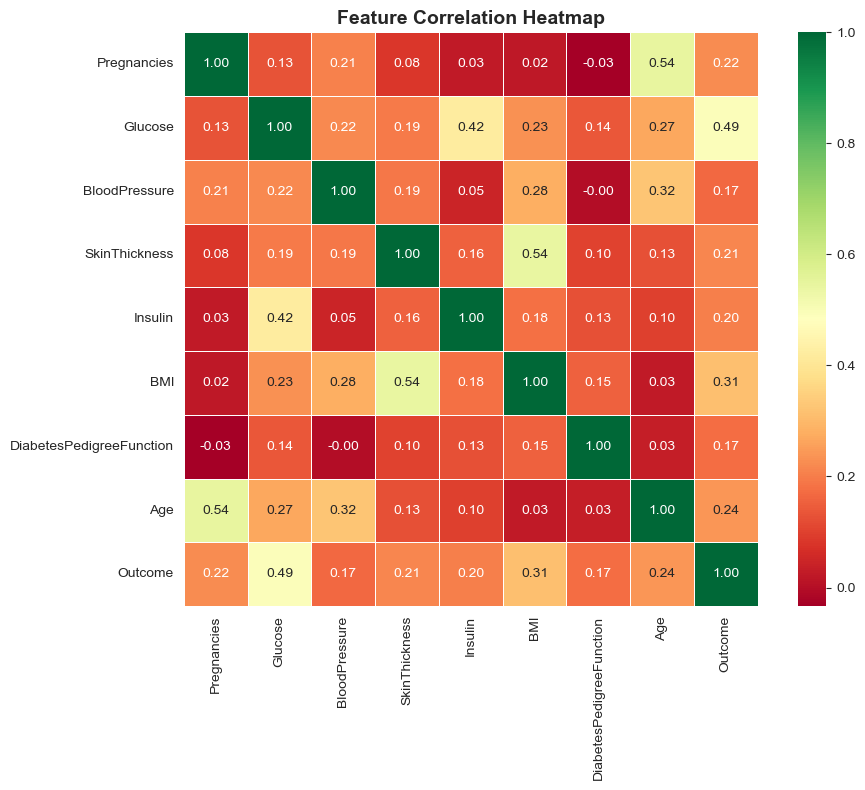

In [13]:
# ================================================
# CELL 13: Correlation Heatmap
# Shows how all features relate to each other
# ================================================

plt.figure(figsize=(10, 8))
correlation = df.corr()

sns.heatmap(correlation,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            linewidths=0.5,
            square=True)

plt.title('Feature Correlation Heatmap',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150)
plt.show()

In [14]:
# ================================================
# CELL 14: Feature Importance Ranking
# Clearly shows which features predict diabetes
# ================================================

print("=" * 50)
print("   TOP FEATURES INFLUENCING DIABETES")
print("=" * 50)

top_features = (correlation['Outcome']
                .drop('Outcome')
                .sort_values(ascending=False))

for rank, (feature, value) in enumerate(top_features.items(), 1):
    bar = "█" * int(abs(value) * 20)
    print(f"{rank}. {feature:28} {value:.4f}  {bar}")

print("\n✅ Glucose is the strongest predictor of diabetes")

   TOP FEATURES INFLUENCING DIABETES
1. Glucose                      0.4928  █████████
2. BMI                          0.3120  ██████
3. Age                          0.2384  ████
4. Pregnancies                  0.2219  ████
5. SkinThickness                0.2149  ████
6. Insulin                      0.2038  ████
7. DiabetesPedigreeFunction     0.1738  ███
8. BloodPressure                0.1657  ███

✅ Glucose is the strongest predictor of diabetes


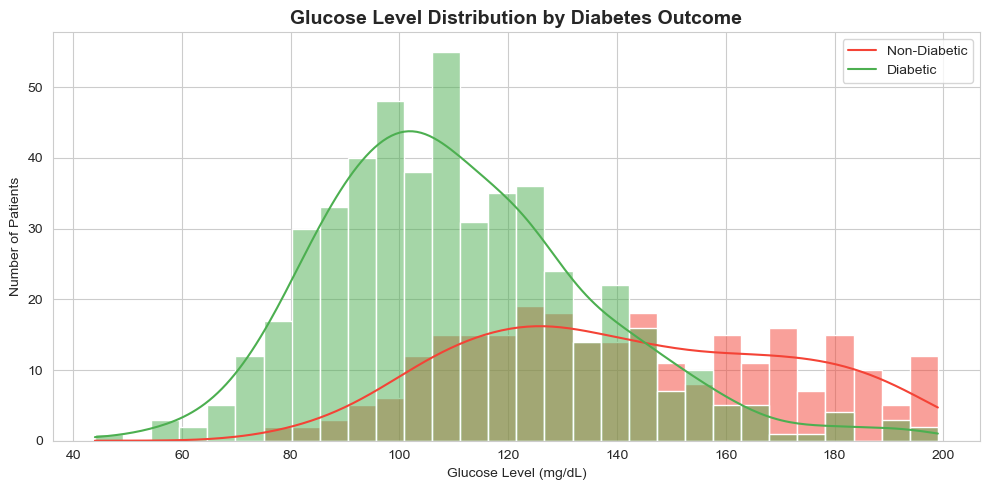

Average Glucose Levels:
----------------------------------------
Outcome
0    110.682000
1    142.130597
Name: Glucose, dtype: float64


In [15]:
# ================================================
# CELL 15: Glucose Distribution Chart
# Most important feature — shown separately
# ================================================

plt.figure(figsize=(10, 5))

sns.histplot(data=df,
             x='Glucose',
             hue='Outcome',
             kde=True,
             palette={0:'#4CAF50', 1:'#F44336'},
             bins=30)

plt.title('Glucose Level Distribution by Diabetes Outcome',
          fontsize=14, fontweight='bold')
plt.xlabel('Glucose Level (mg/dL)')
plt.ylabel('Number of Patients')
plt.legend(['Non-Diabetic', 'Diabetic'])
plt.tight_layout()
plt.savefig('images/glucose_distribution.png', dpi=150)
plt.show()

print("Average Glucose Levels:")
print("-" * 40)
print(df.groupby('Outcome')['Glucose'].mean())

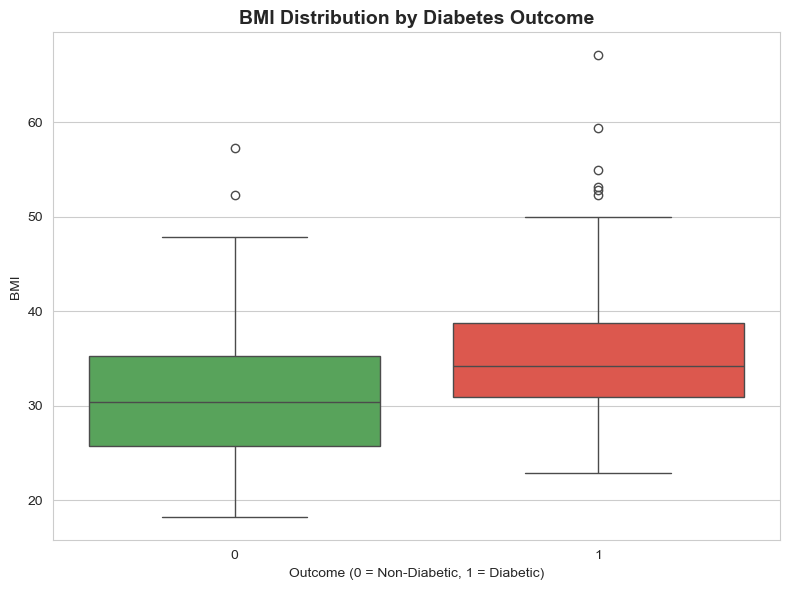

Average BMI:
----------------------------------------
Outcome
0    30.885600
1    35.383582
Name: BMI, dtype: float64


In [16]:
# ================================================
# CELL 16: BMI Box Plot
# ================================================

plt.figure(figsize=(8, 6))

sns.boxplot(data=df,
            x='Outcome',
            y='BMI',
            hue='Outcome',
            palette={0:'#4CAF50', 1:'#F44336'},
            legend=False)

plt.title('BMI Distribution by Diabetes Outcome',
          fontsize=14, fontweight='bold')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('BMI')
plt.tight_layout()
plt.savefig('images/bmi_boxplot.png', dpi=150)
plt.show()

print("Average BMI:")
print("-" * 40)
print(df.groupby('Outcome')['BMI'].mean())

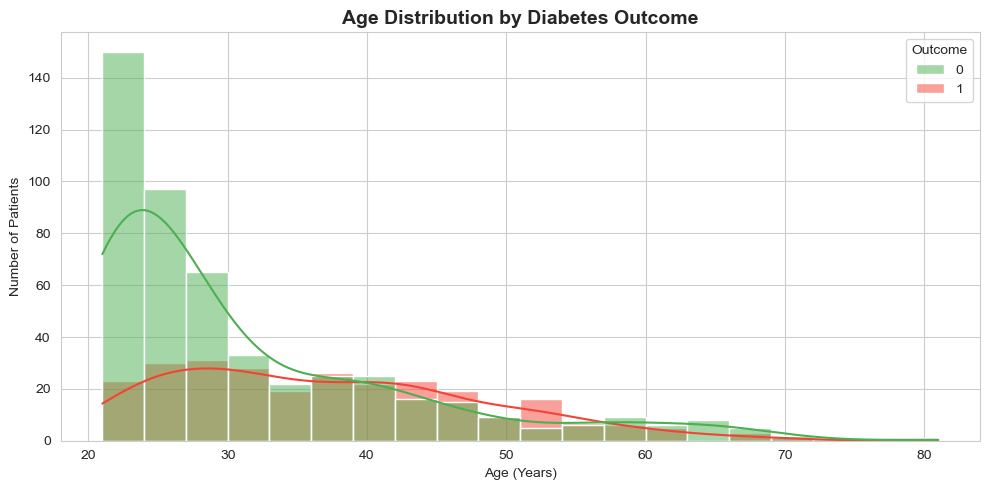

Average Age:
----------------------------------------
Outcome
0    31.190000
1    37.067164
Name: Age, dtype: float64


In [17]:
# ================================================
# CELL 17: Age Distribution Chart
# ================================================

plt.figure(figsize=(10, 5))

sns.histplot(data=df,
             x='Age',
             hue='Outcome',
             kde=True,
             palette={0:'#4CAF50', 1:'#F44336'},
             bins=20)

plt.title('Age Distribution by Diabetes Outcome',
          fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('images/age_distribution.png', dpi=150)
plt.show()

print("Average Age:")
print("-" * 40)
print(df.groupby('Outcome')['Age'].mean())

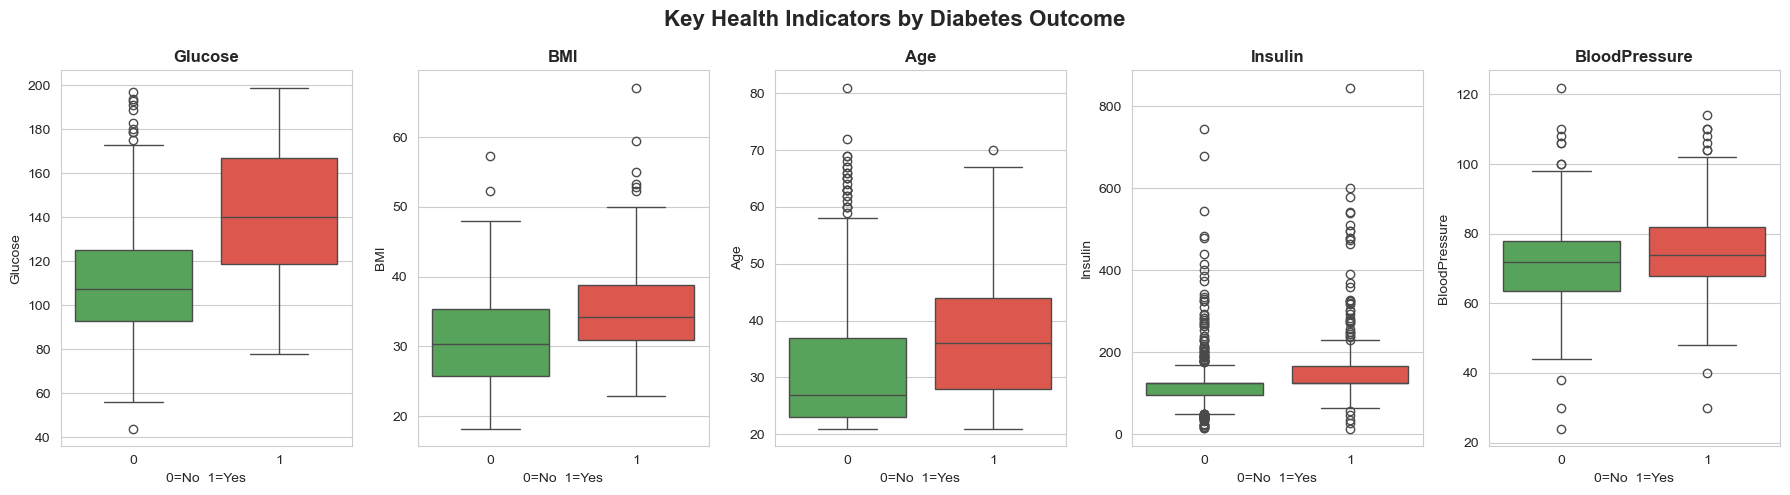

✅ All feature comparison chart saved!


In [18]:
# ================================================
# CELL 18: All Key Features Comparison
# Side by side view of all important features
# ================================================

features = ['Glucose', 'BMI', 'Age', 
            'Insulin', 'BloodPressure']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, feature in enumerate(features):
    sns.boxplot(data=df,
                x='Outcome',
                y=feature,
                hue='Outcome',
                palette={0:'#4CAF50', 1:'#F44336'},
                legend=False,
                ax=axes[i])
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_xlabel('0=No  1=Yes')

fig.suptitle('Key Health Indicators by Diabetes Outcome',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('images/key_features_comparison.png', dpi=150)
plt.show()

print("✅ All feature comparison chart saved!")

## 💡 Section 4: Key Insights & Conclusions

Summary of the most important findings from this analysis.

In [20]:
# ================================================
# CELL 20: Final Insights Summary
# This is what you explain in interviews
# ================================================

diabetic = df[df['Outcome'] == 1]
non_diabetic = df[df['Outcome'] == 0]

print("=" * 55)
print("      DIABETES ANALYSIS — KEY INSIGHTS")
print("=" * 55)

print(f"""
📊 DATASET OVERVIEW
→ Total Patients   : {len(df)}
→ Diabetic         : {len(diabetic)} ({len(diabetic)/len(df)*100:.1f}%)
→ Non-Diabetic     : {len(non_diabetic)} ({len(non_diabetic)/len(df)*100:.1f}%)

🔍 KEY FINDINGS
→ Glucose   : Diabetic avg {diabetic['Glucose'].mean():.1f} vs
              Non-Diabetic avg {non_diabetic['Glucose'].mean():.1f} mg/dL
→ BMI       : Diabetic avg {diabetic['BMI'].mean():.1f} vs
              Non-Diabetic avg {non_diabetic['BMI'].mean():.1f}
→ Age       : Diabetic avg {diabetic['Age'].mean():.1f} vs
              Non-Diabetic avg {non_diabetic['Age'].mean():.1f} years

💡 CONCLUSIONS
1. Glucose is the strongest predictor (0.49 correlation)
2. Diabetic patients have 28% higher glucose levels
3. Higher BMI strongly associated with diabetes
4. Diabetes risk increases significantly with age
5. 48.7% of Insulin values were hidden zeros —
   cleaned using median imputation
""")
print("=" * 55)

      DIABETES ANALYSIS — KEY INSIGHTS

📊 DATASET OVERVIEW
→ Total Patients   : 768
→ Diabetic         : 268 (34.9%)
→ Non-Diabetic     : 500 (65.1%)

🔍 KEY FINDINGS
→ Glucose   : Diabetic avg 142.1 vs
              Non-Diabetic avg 110.7 mg/dL
→ BMI       : Diabetic avg 35.4 vs
              Non-Diabetic avg 30.9
→ Age       : Diabetic avg 37.1 vs
              Non-Diabetic avg 31.2 years

💡 CONCLUSIONS
1. Glucose is the strongest predictor (0.49 correlation)
2. Diabetic patients have 28% higher glucose levels
3. Higher BMI strongly associated with diabetes
4. Diabetes risk increases significantly with age
5. 48.7% of Insulin values were hidden zeros —
   cleaned using median imputation



In [21]:
# ================================================
# CELL 21: Export Cleaned Dataset
# Shows real-world workflow thinking
# ================================================

df.to_csv("cleaned_diabetes_data.csv", index=False)

print("=" * 50)
print("         PROJECT COMPLETE ✅")
print("=" * 50)
print("""
Files saved:
→ cleaned_diabetes_data.csv          ✅
→ images/outcome_distribution.png    ✅
→ images/correlation_heatmap.png     ✅
→ images/glucose_distribution.png    ✅
→ images/bmi_boxplot.png             ✅
→ images/age_distribution.png        ✅
→ images/key_features_comparison.png ✅
""")

         PROJECT COMPLETE ✅

Files saved:
→ cleaned_diabetes_data.csv          ✅
→ images/outcome_distribution.png    ✅
→ images/correlation_heatmap.png     ✅
→ images/glucose_distribution.png    ✅
→ images/bmi_boxplot.png             ✅
→ images/age_distribution.png        ✅
→ images/key_features_comparison.png ✅

